<a href="https://colab.research.google.com/github/elhamod/BA820/blob/main/Text_Mining/Text_Mining_Applications_Basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Course: BA820 - Unsupervised and Unstructured ML**

**Notebook created by: Mohannad Elhamod**

# Book Review Dataset

For illustration purposes, we will use the reviews in [Goodread ratings dataset](https://huggingface.co/datasets/qmaruf/goodreads-rating) to practice text mining applications

## Loading The Data

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

ds = load_dataset("qmaruf/goodreads-rating")

In [ ]:
dataset_df = ds["train"].to_pandas()
dataset_df.drop(columns=["book_id", "user_id", "review_id", "date_added", "date_updated", "read_at", "started_at", "n_votes","n_comments"], inplace=True)

# keep only [1, 5]
dataset_df = dataset_df[dataset_df["rating"].isin([1, 5])]

# take a subset for speeding things up
dataset_df = dataset_df.sample(frac=0.02, random_state=42)

In [ ]:
dataset_df

,rating,review_text
782286,5,This book draws you in. The entire thing is on...
680223,1,Earwig is perfectly happy living in the orphan...
484314,5,this is a definite WOW on the awesome meter......
789331,5,Some Kind of Perfect \n The perfect epilogue t...
819264,5,I've been lucky lately finding all these graph...
...,...,...
640145,5,GENRE: Young Adult - Fiction \n FORM: e-Book \...
121904,5,Wiesner has this rare genius of understatement...
98320,5,6 stars \n Absolutely breathtaking.
179992,5,Oh my gosh. That ending. I neeeeeeeed the next...


In [ ]:
dataset_df.iloc[0]["review_text"]

"This book draws you in. The entire thing is one big mystery/conspiracy/puzzle that is consistently changing, much like the main character and, we are left to assume, the landscape. \n What I enjoyed the most was how it stuck to the same location. Other than flashbacks, the book starts and ends in Area X. And for a novel where, really, not a lot happens, it was still an experience. VanderMeer has a way of drawing you in; I love everything of his I've read (so far), and this was no exception. He's a master, in my opinion, of tone. Though only a smidgen of creepy things actually happen, this novel is ... foreboding. Everything just reeks of malice; whenever the biologist turned a corner I was just waiting for something to pop out at her. \n Likewise, each location was unsettling in a different way. The Tower seemed an almost alien threat, the reeds where the moaning creature resided gave off a supernatural vibe, and the lighthouse bespoke of human violence. In fact, when she was describi

A train/test split might be useful later.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(dataset_df["review_text"], dataset_df["rating"], test_size=0.2, random_state=42)

## Sentiment Analysis (Unsupervised)

We will use a [`SentenceTransformer`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) to extract text embeddings.

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Examples
sentence = "What an exciting movie!"
embeddings = model.encode([sentence])
print(sentence, ". Embedding size:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


What an exciting movie! . Embedding size: (1, 384)


In [ ]:
# Get the embedding for all reviews
embeddings_train = model.encode(X_train.to_list())
embeddings_test = model.encode(X_test.to_list())

Let's create two reference points for the positive vs. negative reviews and compare to them.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

positive_reference_embedding = model.encode("Really great and captivating. Loved it. I quite enjoyed it!").reshape(1, -1)
negative_reference_embedding = model.encode("Quite boring and got me sleepy. I would not recommend it.").reshape(1, -1)

def get_sentiment_score(embeddings):
  return cosine_similarity(positive_reference_embedding, embeddings) - cosine_similarity(negative_reference_embedding, embeddings)

training_scores = get_sentiment_score(embeddings_train)

threshold =  0.011440901


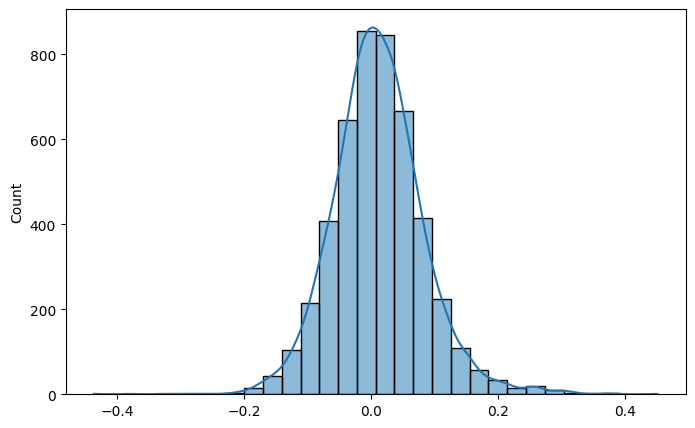

In [ ]:
# Plot histogram of similarity scores
plt.figure(figsize=(8, 5))
sns.histplot(training_scores.reshape(-1), bins=30, kde=True)

threshold_train = np.mean(training_scores)
print("threshold = ", threshold_train)

Let's make sure this threshold works for the test set

In [ ]:
test_scores = get_sentiment_score(embeddings_test)
threshold_test = np.mean(test_scores)
print("threshold = ", threshold_test)

threshold =  0.007862909


We could standardize to place the mean at zero.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Get the embeddings
embeddings = model.encode(dataset_df["review_text"].tolist())

# Get the scores
sentiment_score = get_sentiment_score(embeddings)

# Create Scalar
scaler = StandardScaler()
scaler.fit(training_scores.reshape(-1, 1))
# Scale the scores
dataset_df["sentiment_score"] =  scaler.transform(sentiment_score.reshape(-1, 1)).reshape(-1).tolist() # Get the sentiment score.

# Threshold the scores
dataset_df["positive?"] = dataset_df["sentiment_score"].apply(lambda x: "yes" if x > 0 else "no") # Threshold it.

In [ ]:
dataset_df.sort_values(by="sentiment_score", ascending=False)

,rating,review_text,sentiment_score,positive?
496825,5,Captivating. Loved it!,7.621047,yes
850763,5,Beautifully written. Captivating.,6.098118,yes
284286,5,"Absolutely stunning, beautiful, and inspiring....",5.701999,yes
322028,5,Very authentic. Captured the emotion so well.,5.100321,yes
510203,5,Gorgeous artwork. I'm really glad I got to rea...,4.975208,yes
...,...,...,...,...
824029,5,Every time I finish a book in this series I wa...,-3.852657,no
697956,1,The story wasn't interesting for me.,-4.183577,no
614049,1,It was so. boring.,-4.710228,no
549873,1,Boring and not romantic at all.,-5.449618,no


Let's see the distribution of sentiment vs. ratings

<Axes: xlabel='rating', ylabel='sentiment_score'>

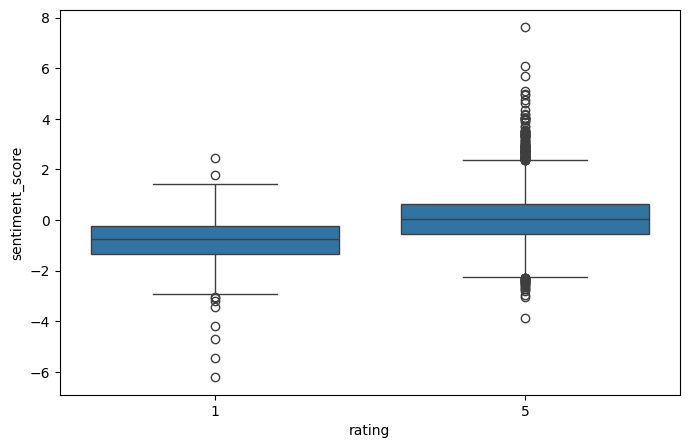

In [ ]:
# show boxplot. x axis is rating. y axis is sentiment score
plt.figure(figsize=(8, 5))
sns.boxplot(x="rating", y="sentiment_score", data=dataset_df)

## **Questions:**

- How much do the ratings agree with the detected sentiments? How would you use the concepts you learned here to discard ratings that do not match with the review's sentiment?
- Would a mean pre-trained `word2vec` model yield good unsupervised sentiment analysis results? Why or why not?
- You are tasked with devising a way for detecting how political a review is. How would you go about implementing that?
- Can you find and use a pre-trained `huggingface` sentiment analysis model on this dataset? How does the pre-trained model compare to your unsupervised approach?

## Topic Modeling

Let's extract the top 3 themes in this dataset

In [ ]:
n_components = 10

Let's first represent the reviews as tokens

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer with the custom tokenizer
vectorizer = CountVectorizer(stop_words='english', lowercase=True, strip_accents='unicode', max_features=1000, max_df=0.1, min_df=100)

# Apply BoW to the training data
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)


Now, apply NMF to the training set

In [ ]:
from sklearn.decomposition import NMF

# Build the model
model = NMF(n_components=n_components, random_state=42)

feature_names = vectorizer.get_feature_names_out()

# Fit and transform
W = model.fit_transform(X_train_bow) # User reviews is terms of topics.
H = pd.DataFrame(model.components_, columns=feature_names) # Topics in terms of tokens
display(H)

,10,able,absolutely,action,actual,add,added,admit,adult,adventure,...,wow,write,writer,wrong,ya,yeah,year,years,yes,young
0,0.310903,0.308678,0.643107,0.376966,0.069921,0.095254,0.000000,0.607531,0.001764,0.048202,...,0.447343,0.419752,0.000000,0.624771,0.256175,0.884129,0.000000,0.000000,2.703785,0.000000
1,0.033052,0.004539,0.000000,0.003985,0.017050,0.041459,0.000000,0.000000,0.000000,0.115339,...,0.037622,0.031261,0.023199,0.053746,0.000000,0.006376,0.015459,0.240663,0.104579,0.000000
2,0.000000,0.000000,0.082660,0.064455,0.000000,0.032659,0.023792,0.000000,0.004075,0.000000,...,0.031656,0.174873,0.137682,0.182866,0.384764,0.000000,0.155373,0.050656,0.093710,0.005568
3,0.127675,0.088541,0.087896,0.099322,0.000000,0.120016,0.082702,0.180981,0.002343,0.000000,...,0.209633,0.005991,0.000000,0.292850,0.000000,0.017607,0.000000,0.211423,0.004981,0.000000
4,0.042315,0.437454,0.844142,0.783826,0.240803,0.179986,0.174865,0.084839,0.280168,0.248349,...,0.199807,0.365992,0.242302,0.224951,0.380183,0.000000,0.274191,0.256069,0.008212,0.435339
5,0.231225,0.000000,0.018581,0.000000,0.049695,0.030050,0.082697,0.000000,0.203603,0.118510,...,0.070204,0.000000,0.030046,0.262179,0.308322,0.026548,1.555180,0.448636,0.000000,0.709889
6,0.000000,0.000000,0.000000,0.113329,0.177867,0.009822,0.000000,0.000000,0.098821,0.000000,...,0.018006,0.011694,0.210354,0.061366,0.000000,0.065061,0.046916,0.192833,0.070518,0.309382
7,0.059274,0.810713,0.000000,0.000000,0.015094,0.000000,0.000000,0.000000,0.038889,0.012503,...,0.000000,0.012728,0.000000,0.005918,0.000000,0.000000,0.509644,0.821522,0.000000,0.363352
8,0.000000,0.516713,0.454291,0.012761,0.037343,0.000000,0.109981,0.011221,0.189791,0.000000,...,0.018595,0.157392,0.000000,0.039980,0.166583,0.000000,0.474474,0.989988,0.000000,0.206204
9,0.013545,0.205628,0.000000,0.000000,0.079315,0.000000,0.000000,0.048952,0.000000,0.018209,...,0.000000,0.213128,0.030914,0.272695,0.000000,0.004044,0.033074,0.631662,0.000000,0.000000


Let's plot the *n* topics in terms of the top books that represent them

In [ ]:
!pip install mglearn

In [ ]:
import mglearn

mglearn.tools.print_topics(topics=range(n_components), feature_names=feature_names,
                           sorting=np.argsort(model.components_, axis=1)[:, ::-1], n_words=5, topics_per_chunk=1)




topic 0       
--------      
yes           
oh            
bad           
kind          
let           


topic 1       
--------      
spoiler       
view          
hide          
happy         
isn           


topic 2       
--------      
page          
said          
tell          
forever       
living        


topic 3       
--------      
man           
woman         
wants         
let           
past          


topic 4       
--------      
magic         
interesting   
stories       
enjoyed       
point         


topic 5       
--------      
school        
girl          
high          
year          
friend        


topic 6       
--------      
king          
gets          
mother        
men           
dead          


topic 7       
--------      
day           
brother       
years         
able          
live          


topic 8       
--------      
family        
relationship  
father        
years         
friends       


topic 9       
--------      
believe

Topic 0:
Topic 1:
Topic 2:
Topic 3:
Topic 4:
Topic 5:
Topic 6:
Topic 7:
Topic 8:
Topic 9:


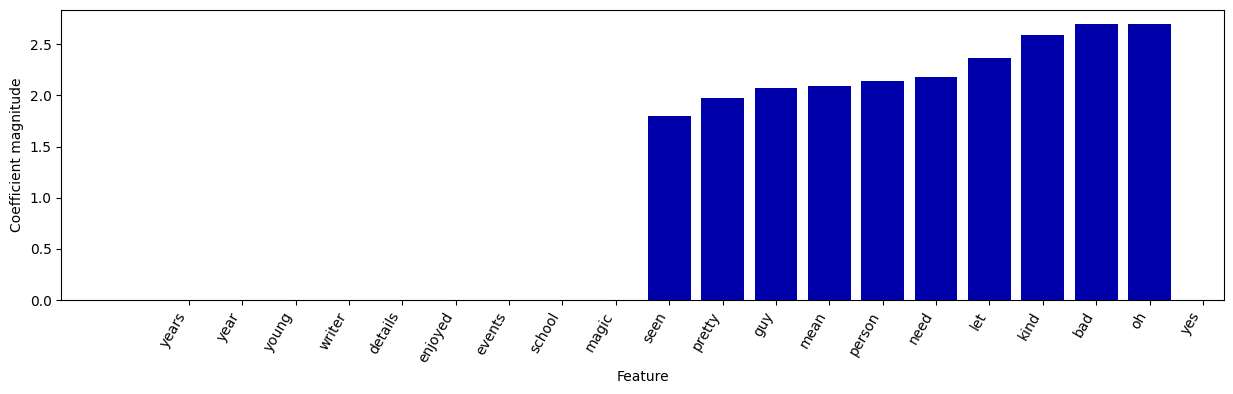

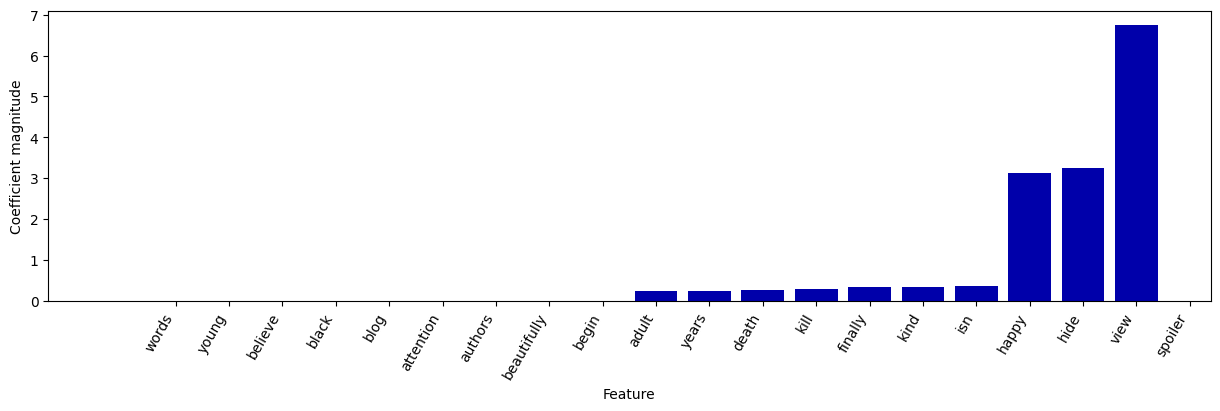

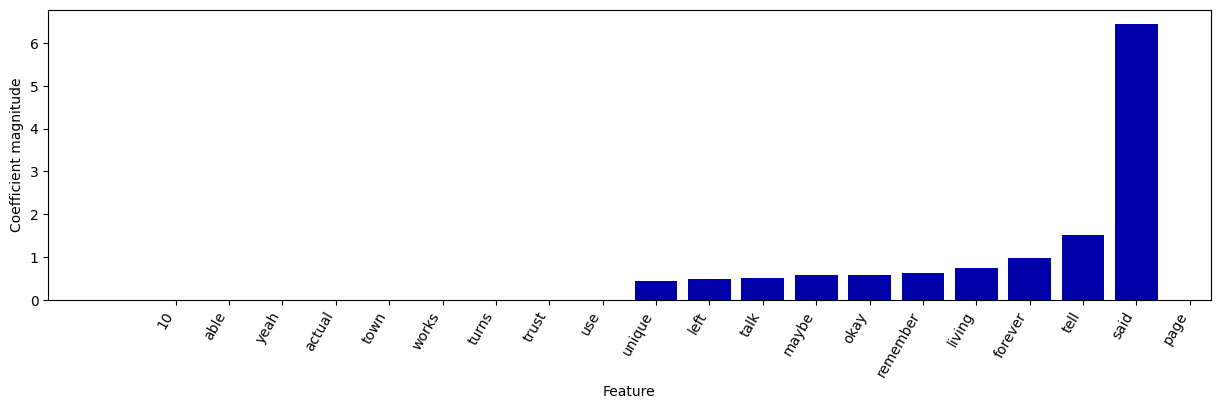

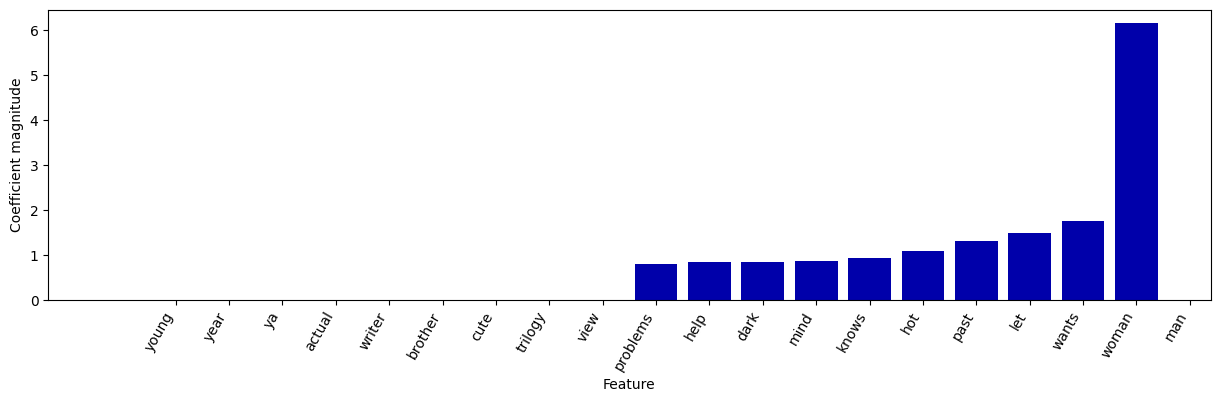

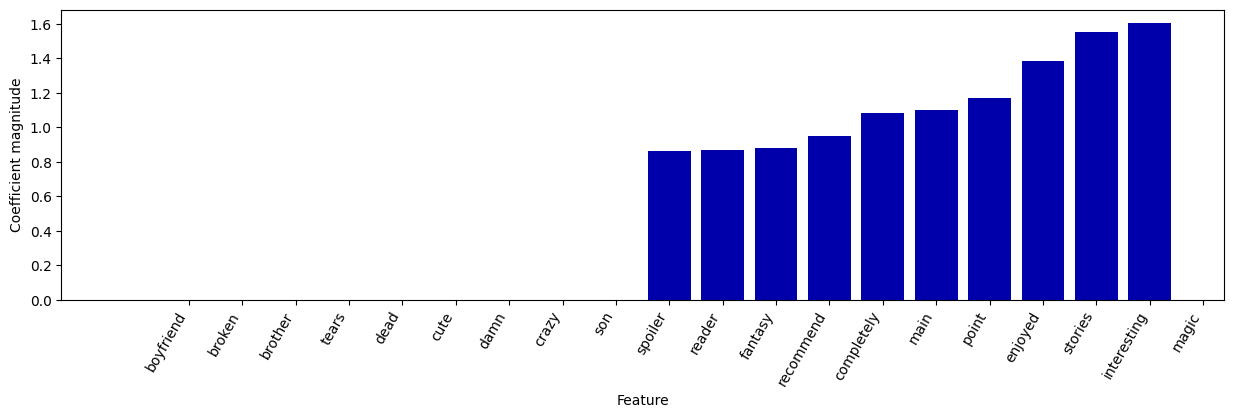

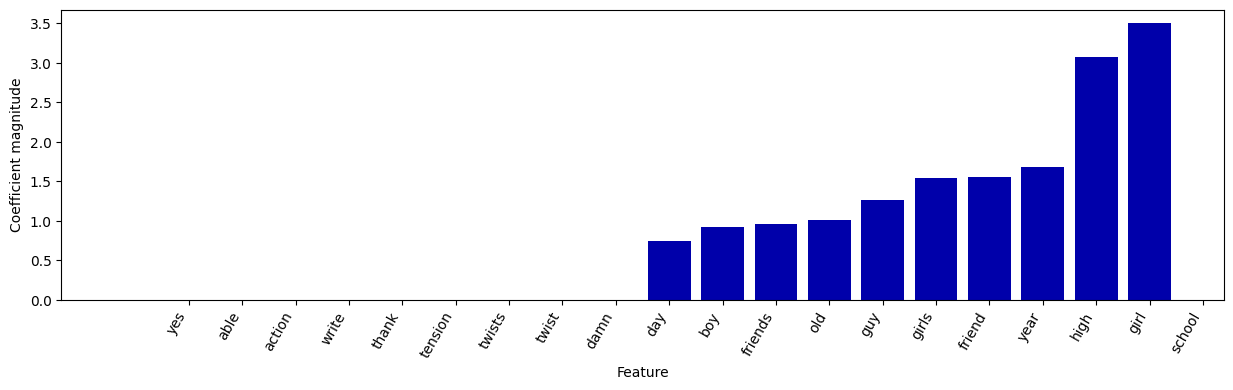

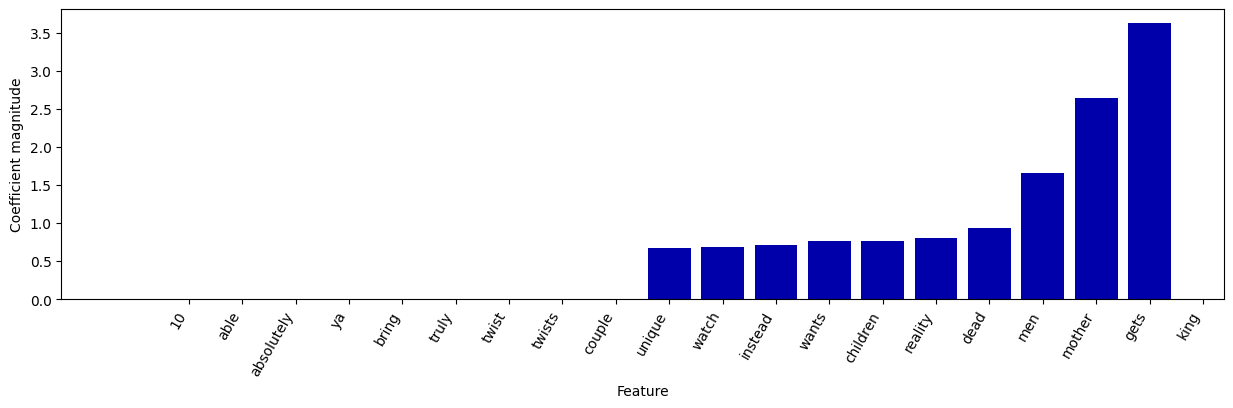

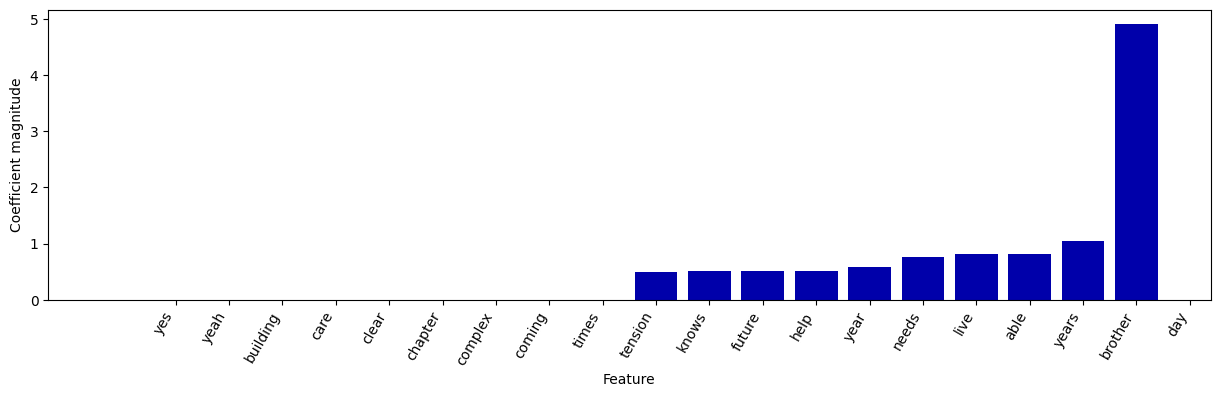

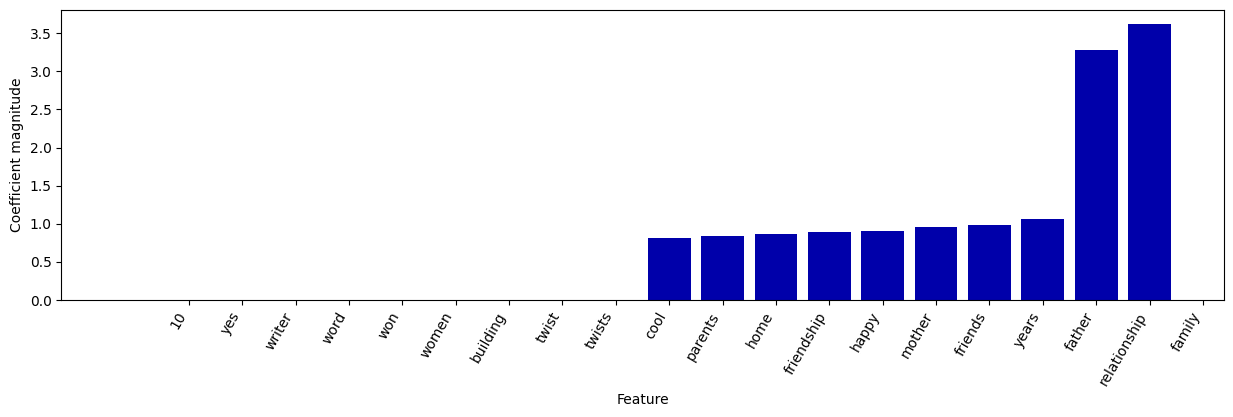

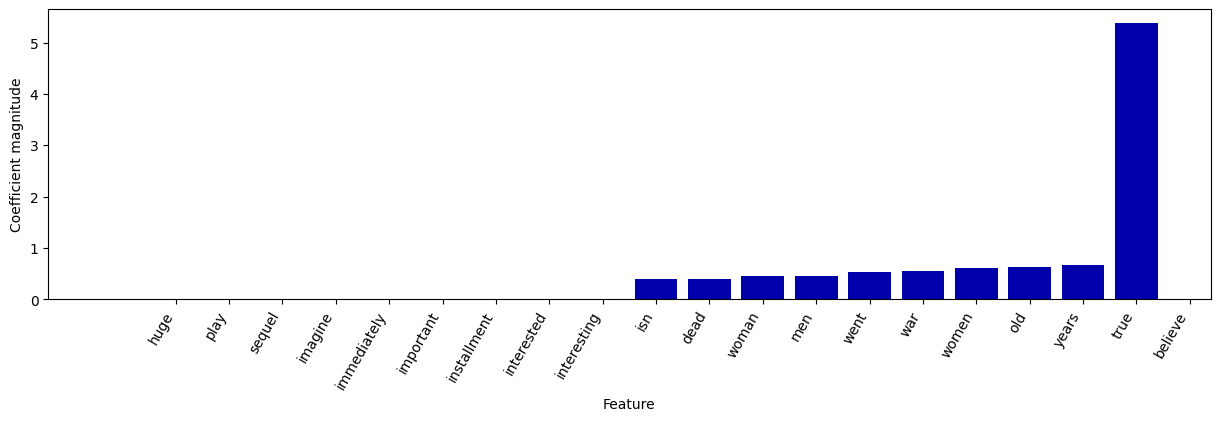

In [ ]:
for i in range(n_components):
  print(f"Topic {i}:")
  mglearn.tools.visualize_coefficients(model.components_[i], feature_names, n_top_features=10)

In [ ]:
print(f"Displaying top {n_components} topics in terms of reviews:")
for i, topic_words in enumerate(H.values):
    print(f"\nTopic {i}:")
    # Get the indices of the top reviews for the current topic
    top_review_indices = np.argsort(W[:, i])[::-1][:5] # Get top 5 reviews
    for idx in top_review_indices:
        review_text = X_train.iloc[idx]
        print(f"  - Score: {W[idx, i]:.4f}, Review: {review_text[:300]}...")

Displaying top 10 topics in terms of reviews:

Topic 0:
  - Score: 1.4288, Review: Hey, hey Mr. DJ, could we get some Adele up in here. This shit is about to get real emotional. 
 Look at that melted pile of goo on the floor, wonder who that is... Oh never-mind that's just me. SO EMOTIONAL. This book had its ups and downs which was why it turned out to score amazing and well deser...
  - Score: 0.8590, Review: This review was done with my wonderful co-blogger Celeste and our great friend Sim at The Book Hookup! 
 First Thoughts: 
 Celeste: 5 red smoking hot stars! I have all the feels. All. Of. The. Feels. This book got me hooked for so many reasons. I couldn't get enough. If there is any romantic in you ...
  - Score: 0.8107, Review: I have to admit, that was a pretty crappy book. I went into it without any big expectations- I mean, LOOK at this cover! 
 WTF? - and it was every bit as bad as I thought it would be, if not worse. 
 First, of all, Rose. Everyone, meet the bitchiest YA pr

Instead of comparing reviews in terms of tokens, they can now be compared in terms of topics. This is called **collaborative filtering**.

In [ ]:
new_review = "I really loved the book. It was captivating. The boy and the girl fell in love and lived happily ever after!"

new_review_bow = vectorizer.transform([new_review])
new_review_topic_scores = model.transform(new_review_bow)

print("New review topic scores:")
for i in range(n_components):
  print(f"Topic {i}: {new_review_topic_scores[0, i]}")
print("\t")

# Find the top 5 sentences most similar to this sentence based on topics
similarity_scores = np.dot(new_review_topic_scores, W.T)
top_indices = np.argsort(similarity_scores[0])[::-1][:5]
print("Top 5 sentences most similar to the new review:")
for idx in top_indices:
  print(f"{similarity_scores[0][idx]:.4f} - {X_train.iloc[idx]}\n")



New review topic scores:
Topic 0: 0.006996832654434927
Topic 1: 0.0
Topic 2: 0.0
Topic 3: 0.0
Topic 4: 0.0
Topic 5: 0.0873827313706681
Topic 6: 0.0
Topic 7: 0.0
Topic 8: 0.0
Topic 9: 0.0
	
Top 5 sentences most similar to the new review:
0.1738 - " Years before Trip Wiley could be seen on movie screens all over the world, he could be seen in the desk behind me in my high school English class."-Layla Warren 
 Remember When was a witty, funny, swooning, and incredible book that took me right back to high school where we all met our first crushes, first loves, and first heart breaks, where we finally get a glimpse of adult hood,where we learn the meaning of the word change and the world as we know it is ours for the taking. 
 " To Layla. A girl who never stops surprising me."-Trip 
 This is the first time I have read an T. Torrest novel and let me tell you she has definitely won yet another fan, not only because I'm also a Jersey Girl, just like her and just like our amazing Heroine Layla 

##Named Entity Recognition

We will use [`SpaCy` for NER](https://spacy.io/models/en).

In [ ]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 7.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
from spacy import displacy


ner_model = spacy.load("en_core_web_lg") # A pre-trained model that performs NER, among other tasks
# en_core_web_md
# en_core_web_sm
# en_core_web_lg


for sentence in dataset_df["review_text"].head():
  processed_sentence = ner_model(sentence) # Extract entities!

  if len(processed_sentence.ents) != 0:
    # print entities and their types
    for entity in processed_sentence.ents:
      print(f"{entity.text} ({entity.label_})")

    displacy.render(processed_sentence, style="ent")
    print( "-----")


one (CARDINAL)
VanderMeer (ORG)
Tower (PERSON)
Battle Royale (FAC)
two (CARDINAL)


-----
Custard (ORG)
Diana Wynne Jones (PERSON)
Aunt Maria (PERSON)
Diana Wynne Jones (PERSON)


-----
J.R. Ward (PERSON)
BDB (ORG)
Tohr (ORG)
Welsie (ORG)
Tohr (ORG)
Lassiter (PERSON)
Maury (PERSON)
John Mathew (PERSON)
Layla (PERSON)


-----
the Addicted Series (WORK_OF_ART)
Long Way Down (PERSON)
ten years (DATE)
a few years (DATE)
POV (PERSON)
ten years later (DATE)
those years (DATE)
more than a week (DATE)
Long Way Down (WORK_OF_ART)
POV (PERSON)
those ten years (DATE)
each year (DATE)
Meadows (PERSON)
Daisy (PERSON)
Hale (PERSON)
Lo (PERSON)
Ryke (GPE)
Daisy (PERSON)
Moffy (ORG)
Cobalt (ORG)
seven (CARDINAL)
Jane (PERSON)
Eliot (PERSON)
Tom (PERSON)
Tom (PERSON)
Connor (PERSON)
Charlie (PERSON)
Connor (PERSON)
Rose (PERSON)


-----
five (CARDINAL)
ASAP (EVENT)
late nights (DATE)


-----


In [ ]:
import spacy
from spacy import displacy


ner_model = spacy.load("en_core_web_lg") # A pre-trained model that performs NER, among other tasks
# en_core_web_md
# en_core_web_sm
# en_core_web_lg

processed_sentence = ner_model("I live in Boston, MA") # Extract entities!

if len(processed_sentence.ents) != 0:
  # print entities and their types
  for entity in processed_sentence.ents:
    print(f"{entity.text} ({entity.label_})")

  displacy.render(processed_sentence, style="ent")
  print( "-----")

Boston (GPE)
MA (GPE)


-----
